# Single star

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares

In [3]:
np.random.seed(42)

The ``EpochAstrometry`` class is used for storing Gaia epoch astrometry. In the future, we can either retrieve the data from the archive. For now, we can simulate epoch astrometry for Gaia DR4 or DR5. To do so, we can either set the stellar parameters manually or retrieve parameters from DR3. In this example, we will simulate DR4 epoch astrometry for the star [HD 135344 A](https://en.wikipedia.org/wiki/HD_135344).

In [4]:
source_id = 6199395656645840384  # HD 135344 A
primary_mass = (2.2, 0.1)  # (Msun)

In [5]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 2.20 +/- 0.10


Now we query the stellar parameters from Gaia DR3. These will be stored as attributes of the `EpochAstrometry` object and returned as list for convenience.

In [6]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384

INFO: Query finished. [astroquery.utils.tap.core]

RA = 228.954 deg +/- 0.038 mas
Dec = -37.149 deg +/- 0.026 mas
Parallax = 7.411 +/- 0.040 mas
Proper motion in RA = -18.738 +/- 0.051 mas/yr
Proper motion in Dec = -24.008 +/- 0.035 mas/yr
G-band magnitude = 7.748
Pseudocolor = 1.73 um-1

UWE = 1.96
RUWE = 0.95
Astrometric excess noise (mas) = 0.2075 +/- 0.0103
Non single star = 0


We will first simulate epoch astrometry for a single star. In this exmample, we use the retrieved stellar parameters of HD 135344 A.

In [7]:
model_param = epoch_astrom.simulate_data(ra=None, dec=None, parallax=None, pmra=None, pmdec=None, phot_g_mean_mag=None)


-------------
Simulate data
-------------

System type: single

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Stellar parameters:
   - RA (deg) = 228.95
   - Dec (deg) = -37.15
   - Parallax (mas) = 7.41
   - Proper motion in RA (mas/yr) = -18.74
   - Proper motion in Dec (mas/yr) = -24.01
   - G-band magnitude = 7.75


Next, we run a 5-parameter least-squares fit to determine the best-fit parameters and uncertainties of the stellar track.

In [8]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5 parameters)
--------------------------

Reduced chi^2 = 0.988
RUWE = 0.994
F2 estimator = -0.033
Inflation factor = 0.998

Best-fit parameters:
   - RA offset = 0.012 +/- 0.014 mas
   - Dec offset = 0.004 +/- 0.010 mas
   - Parallax = 7.408 +/- 0.016 mas
   - mu in RA = -18.734 +/- 0.009 mas/yr
   - mu in Dec = -24.010 +/- 0.005 mas/yr


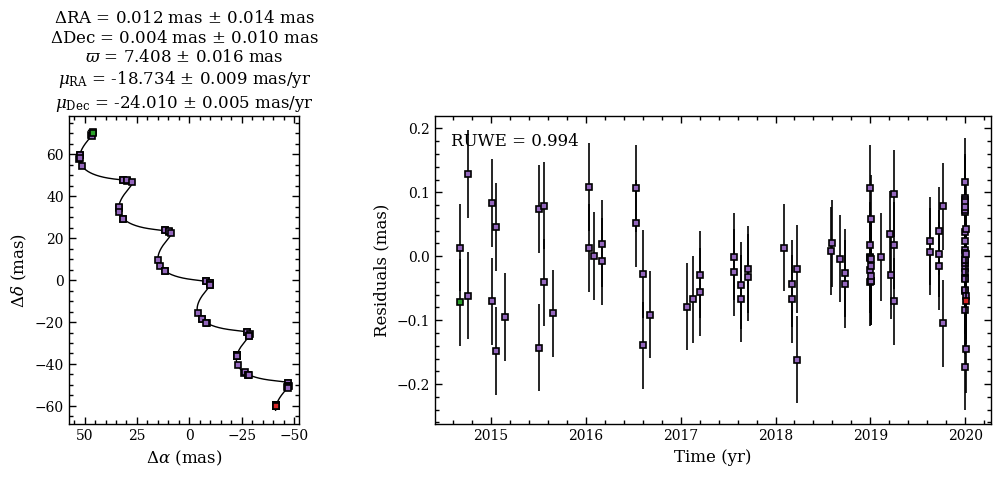

In [9]:
results = leastsq.singl_5param(plot_file='plot.png')